In [193]:
# Load configurations 
from pathlib import Path
import sqlite3
import yaml
import json
import pandas as pd

with open("configs.yml", "r") as f:
    config = yaml.safe_load(f)

db_path = Path(config["data"]["database_path"])
db_meta_path = Path(config["data"]["database_meta_path"]) 
db_conn = sqlite3.connect(config["data"]["database_path"])
table_name = config["data"]["table_name"]

with open(db_meta_path, "r") as f:
    metadata = json.load(f)
    numeric_cols = metadata["columns"]["numeric"]
    cat_cols = metadata["columns"]["categorical"]
    gt_col = metadata["columns"]["ground_truth"]

# test database connection by reading table info using pandas
table_info = pd.read_sql_query(
    f"PRAGMA table_info({table_name});",
    db_conn
)

table_info


,cid,name,type,notnull,dflt_value,pk
0,0,CustomerType,TEXT,0,None,0
1,1,SpecialDayProximity,REAL,0,None,0
2,2,ExitRate,REAL,0,None,0
3,3,PageValue,REAL,0,None,0
4,4,TrafficSource,REAL,0,None,0
5,5,GeographicRegion,INTEGER,0,None,0
6,6,BounceRate,REAL,0,None,0
7,7,ProductPageTime,REAL,0,None,0
8,8,PurchaseCompleted,INTEGER,0,None,0


In [194]:
# Since we are conducting EDA, simply load the entire table in memory for ease of analysis
df = pd.read_sql_query(
    f"SELECT * FROM {table_name};",
    db_conn
)
df.head(10)

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
0,Returning_Visitor,0.0,0.200000,0.0,1.0,1,0.200000,0.000000,0
1,Returning_Visitor,0.0,0.100000,0.0,2.0,1,0.000000,64.000000,0
2,Returning_Visitor,NaN,0.200000,0.0,3.0,-9,0.200000,0.000000,0
3,Returning_Visitor,0.0,0.140000,0.0,4.0,2,0.050000,2.666667,0
4,Returning_Visitor,0.0,NaN,NaN,4.0,1,0.020000,627.500000,0
5,Returning_Visitor,0.0,0.024561,0.0,3.0,1,0.015789,154.216667,0
6,Returning_Visitor,0.4,0.200000,0.0,3.0,3,0.200000,0.000000,0
7,Returning_Visitor,0.0,0.200000,0.0,5.0,1,0.200000,NaN,0
8,,0.8,0.100000,0.0,3.0,2,0.000000,37.000000,0
9,Returning_Visitor,0.4,0.022222,0.0,2.0,1,0.000000,738.000000,0


In [195]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerType         12330 non-null  str    
 1   SpecialDayProximity  11714 non-null  float64
 2   ExitRate             11714 non-null  float64
 3   PageValue            11714 non-null  float64
 4   TrafficSource        11714 non-null  float64
 5   GeographicRegion     12330 non-null  int64  
 6   BounceRate           12330 non-null  float64
 7   ProductPageTime      11714 non-null  float64
 8   PurchaseCompleted    12330 non-null  int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 867.1 KB


In [196]:
# The above shows the existence of missing values, consider dropping rows with missing values 
num_of_na_rows = df.isna().any(axis=1).sum()
print(f"Number of rows with at least one NA value: {num_of_na_rows}") # 2778 rows with NA

# Though the number of rows with NA is not negligible,
# We still consider dropping them for simplicity as we still left with sizable data (9952 rows)
# Replacing NA with default/estimated values may introduce significant bias, so we choose to drop them instead
df_no_na = df.dropna() # df_no_na: dataframe with no NA values
df_no_na.info()

Number of rows with at least one NA value: 2778
<class 'pandas.DataFrame'>
Index: 9552 entries, 0 to 12329
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerType         9552 non-null   str    
 1   SpecialDayProximity  9552 non-null   float64
 2   ExitRate             9552 non-null   float64
 3   PageValue            9552 non-null   float64
 4   TrafficSource        9552 non-null   float64
 5   GeographicRegion     9552 non-null   int64  
 6   BounceRate           9552 non-null   float64
 7   ProductPageTime      9552 non-null   float64
 8   PurchaseCompleted    9552 non-null   int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 746.2 KB


In [197]:
# For categorical columns, we encode them into numeric values for later numeric analysis.
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    df_no_na[col] = LabelEncoder().fit_transform(df_no_na[col])

# create dataframe with no ground truth labels    
df_no_gt = df_no_na.drop(columns=[gt_col])

In [ ]:
# We are doing this to find out class imbalance in the dataset
class_cnts = df_no_na[gt_col].value_counts()
class_props = df_no_na[gt_col].value_counts(normalize=True)

print("Class Distribution: ")
for cls in class_cnts.index:
    print(f"{gt_col}={cls}:  {class_cnts[cls]} samples  ({class_props[cls]*100:.1f}%)")
    
# High class imbalance is observed (84.4 : 15.6)
# We shall use metrics such as F1-score or AUC-ROC to replace classic accuracy for model evaluation
# as accuracy becomes meaningless (e.g. model predicting all 0 can already achieve 84.4% accuracy)


Class Distribution: 
PurchaseCompleted=0:  8064 samples  (84.4%)
PurchaseCompleted=1:  1488 samples  (15.6%)


<Axes: >

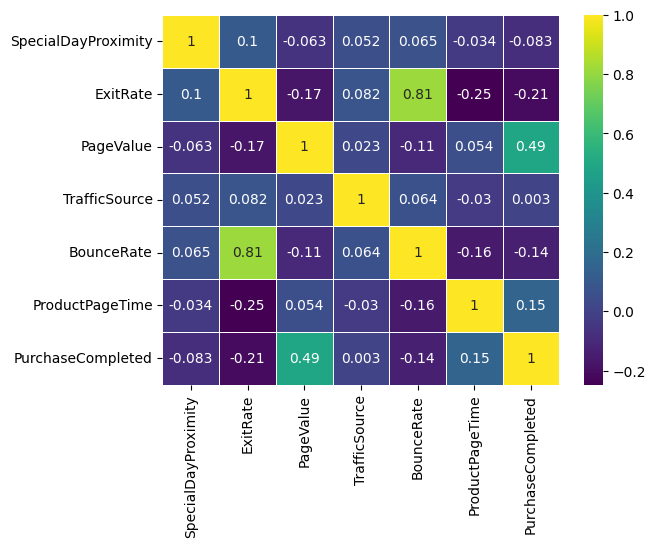

In [199]:
# The correlation heatmap between numeric pairs only shows 
# strong correlation between BounceRate and ExitRate 
# which can be expected as bounce rate is a subset of exit rate
# The rest are weakly correlated which suggest they are independent features
# It is also observable that PageValue is moderately correlated with the ground truth label
# indicating it may be the most impactful feature for predicting purchase intent
import seaborn as sns
sns.heatmap(df_no_na[numeric_cols + [gt_col]].corr(), annot=True, cmap="viridis", linewidths=0.5)

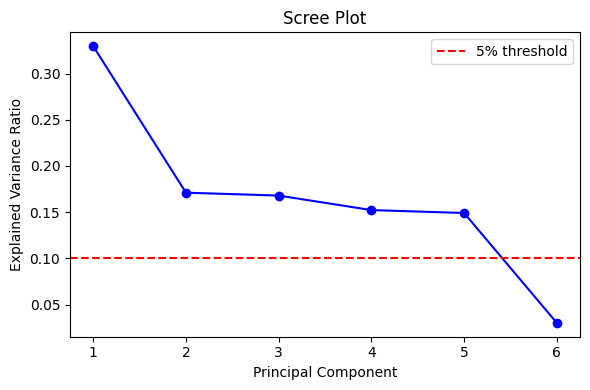

In [200]:
# we also interested in PCA to find out how many principal components are needed to explain the variance in the data
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply standard scaling to prevent PCA from being dominated by features with larger scales
# Only interested in numeric features as categorical features may 
scaler = StandardScaler()
df_for_pca = scaler.fit_transform(df_no_gt[numeric_cols])

pca = PCA()
pca.fit(df_for_pca)

explained_var = pca.explained_variance_ratio_
fig = plt.figure(figsize=(6, 4))

plt.plot(range(1, len(explained_var) + 1), explained_var, "bo-", markersize=6)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.axhline(y=0.1, color="r", linestyle="--", label="5% threshold")
plt.legend()

plt.tight_layout()
plt.show()

# The scree plot shows that we need to keep all 6 numeric dimensions
# to ensure 95% of the variance is explained
# This suggests the non-linearity and high complexity of the patterns exist in high dimensions


In [201]:
# We further apply UMAP to reduce the dimensionality 
# and try out whether we are able to visually separate the two classes
# this helps us understand the patterns of data in high dimensions

import plotly.graph_objects as go
from umap import UMAP

umap_result = UMAP(n_components=3).fit_transform(df_no_gt)
umap_result = pd.DataFrame(umap_result, columns=["1", "2", "3"])
umap_df = pd.concat([umap_result, df_no_na[gt_col].reset_index(drop=True)], axis=1)

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=umap_df["1"],
            y=umap_df["2"],
            z=umap_df["3"],
            mode="markers",
            marker=dict(
                size=4,
                color=umap_df[gt_col],
                colorscale="Viridis",
                opacity=0.8,
                colorbar=dict(title=gt_col),
            ),
        )
    ]
)

fig.update_layout(
    title="UMAP reduction",
    scene=dict(xaxis_title="1", yaxis_title="2", zaxis_title="3"),
)
fig.show()

# However the 3D UMAP plot suggests there is no clear-cut separation 
# between two-class purchase intent
# From both PCA and UMAP dimentionality reduction methods,
# We can conclude that non-linear models shall be used to capture the complex patterns
# e.g. XGBoost, SVM with RBF kernel, or MLP 

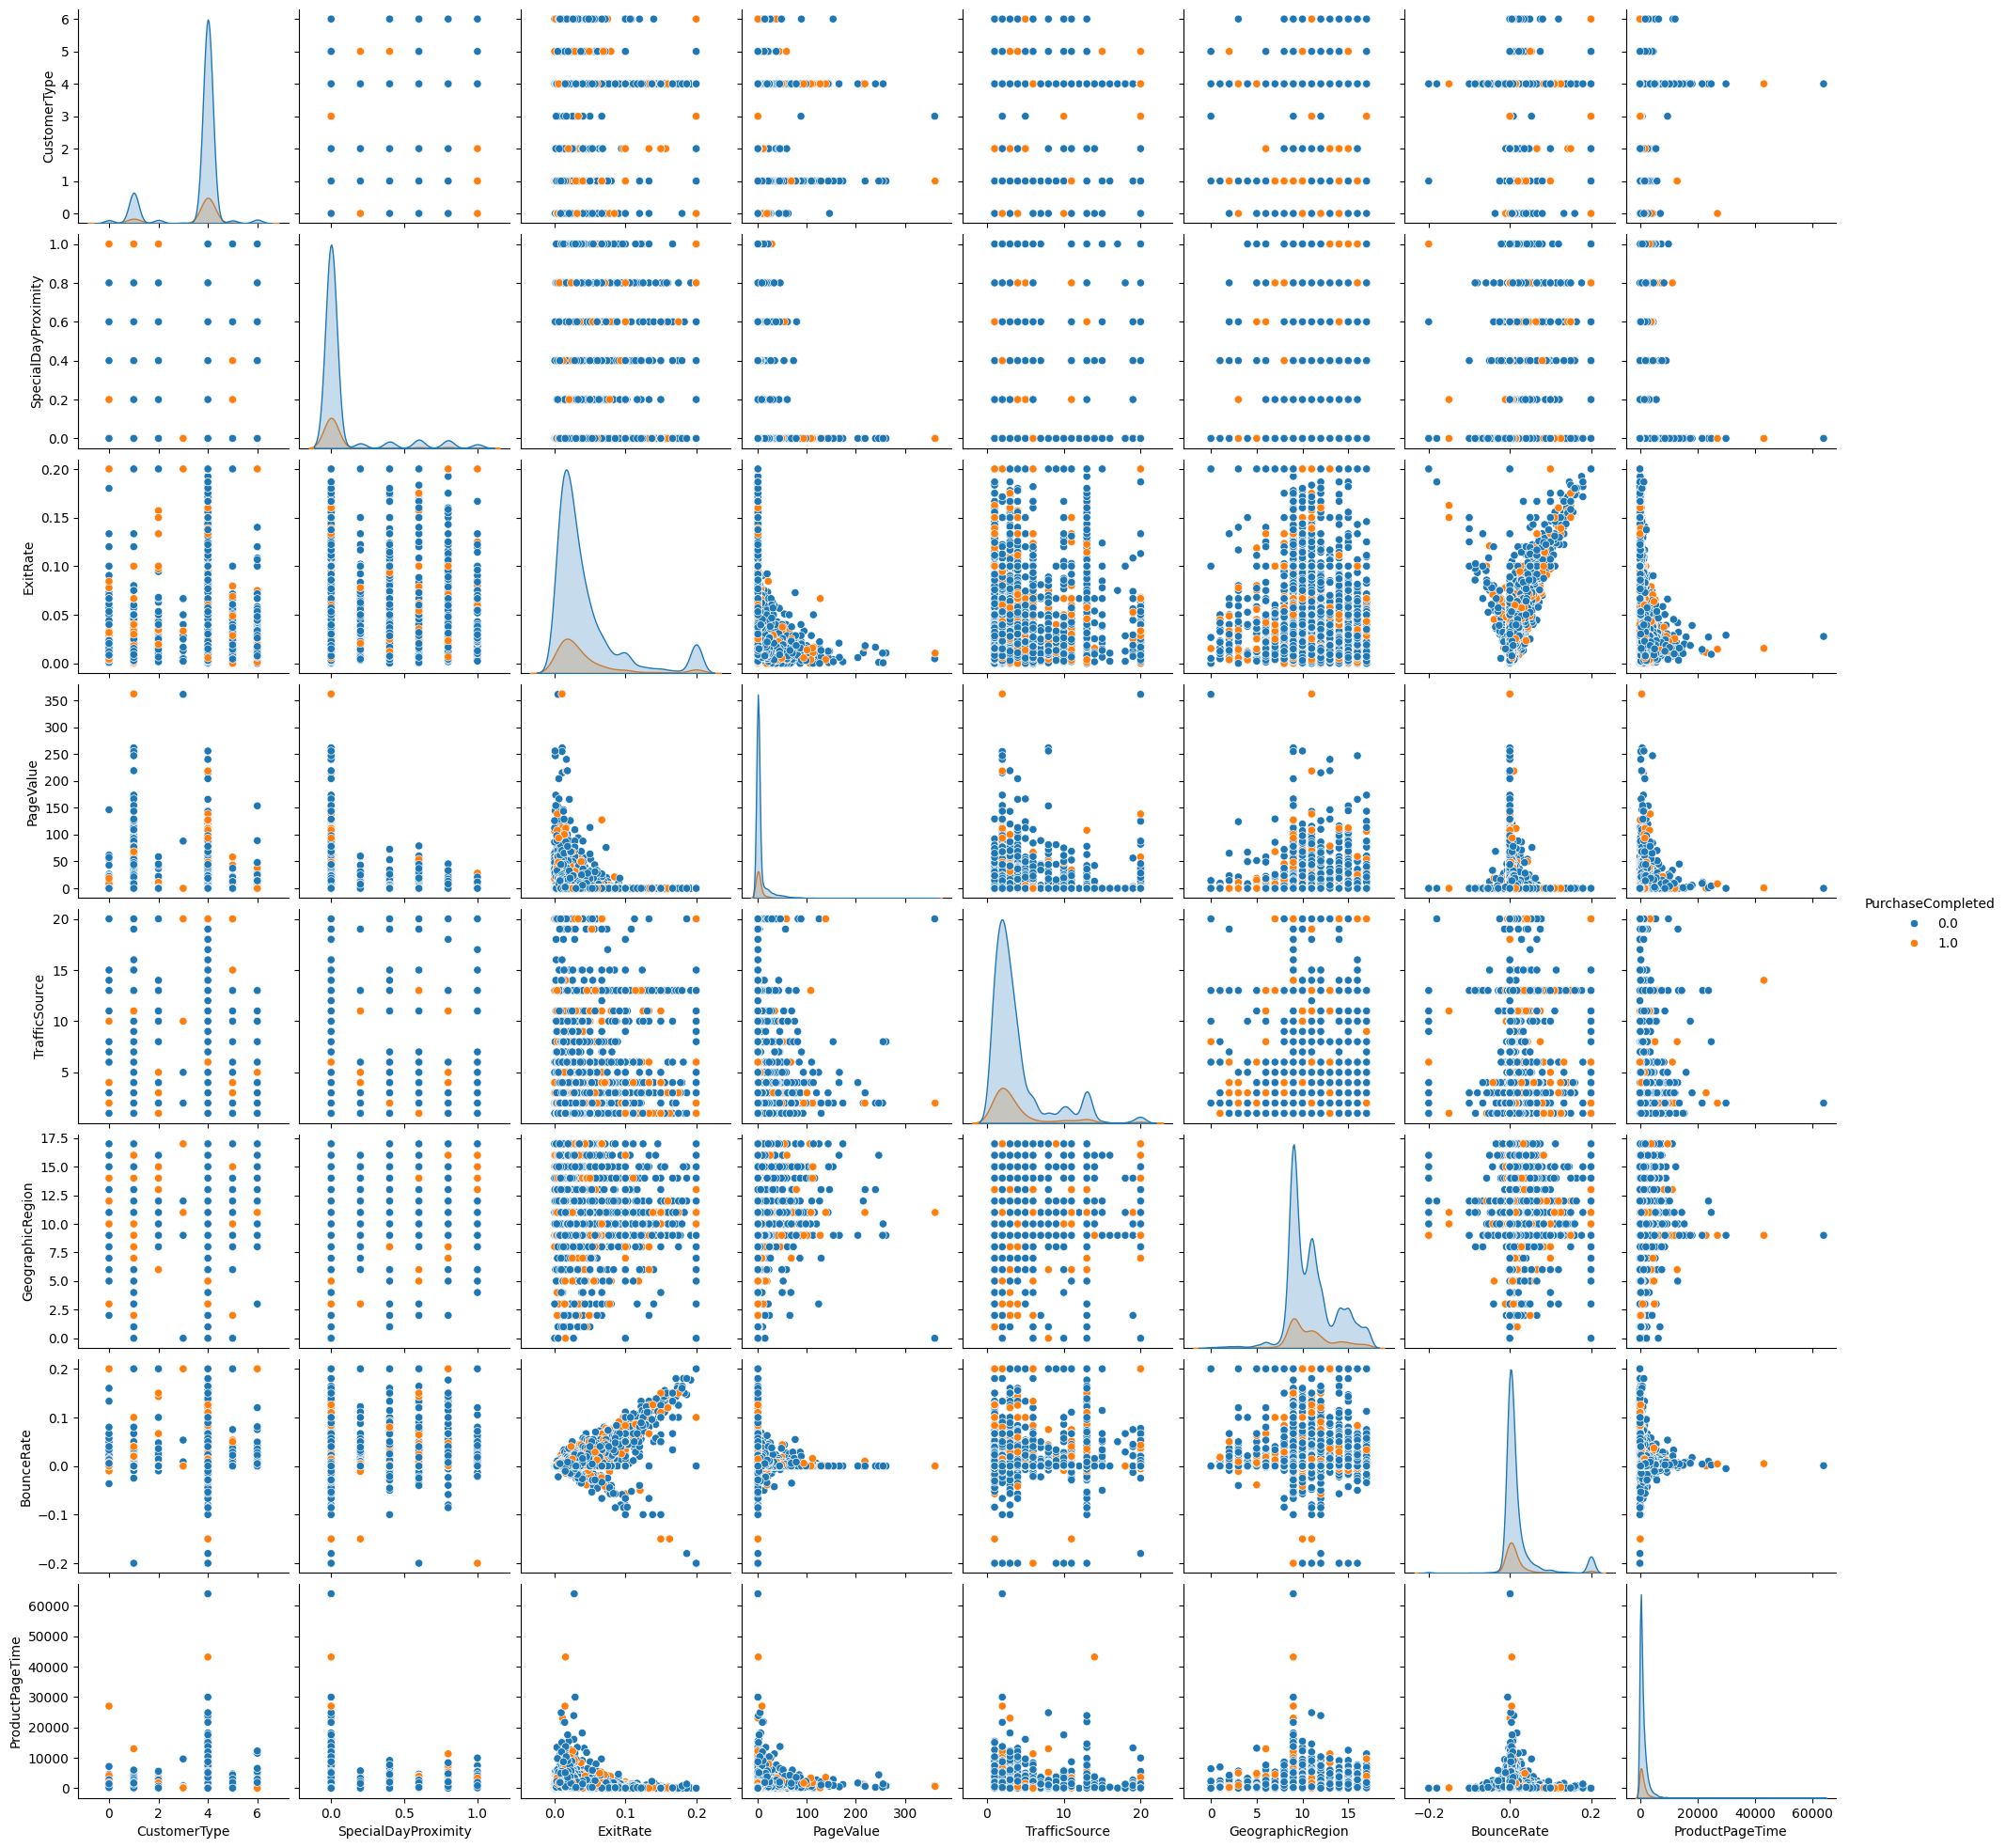

In [202]:
# we perform pairwise scatter plots to give another view angle of 
# the data distribution in high dimensions
# Again there is no clear-cut separation found
df_with_gt = pd.concat([df_no_gt, df_no_na[gt_col].reset_index(drop=True)], axis=1)
sns.pairplot(df_with_gt, hue=gt_col)

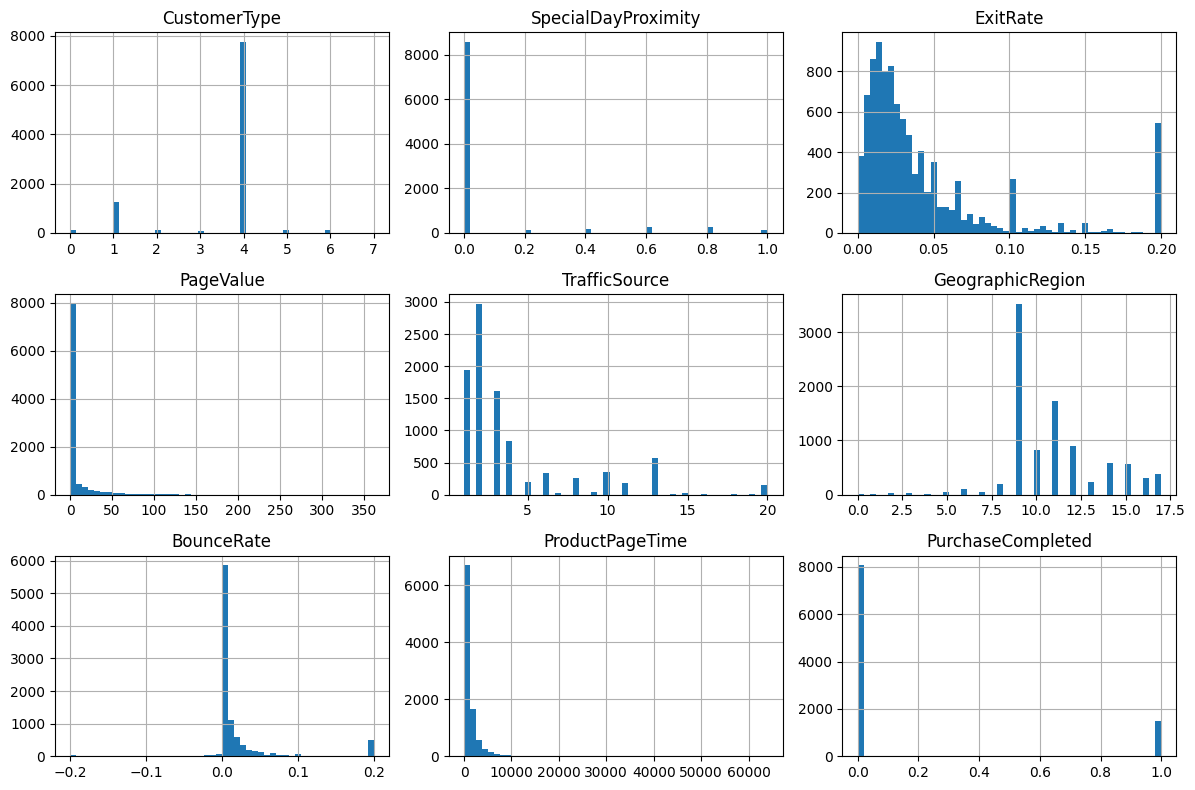

In [ ]:
# From the above pair plots, it is observable that some distributions are extremely skewed
import numpy as np

# We use histograms to visualize and found out that some features have extremely skewed distributions
# Highly skewed features e.g. SpecialDayProximity, PageValue, BounceRate, ProductPageTime 
# Alghouth these may not affect tree-based models,
# they may affect euclidean distance-based/gradient-based models
df_no_na.hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Later we may consider log transform to be involved in the data preprocessing pipeline
# before feeding data into models such as SVM or MLP

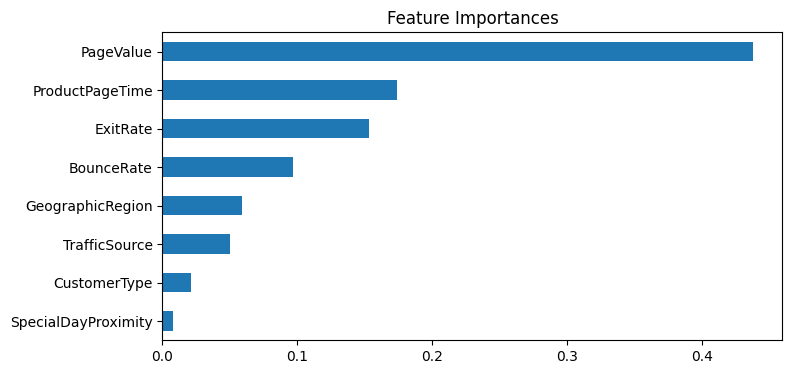

In [ ]:
# On the other hand, we shall futher investigate the feature importance 
# We can use a simple Random Forest model to confirm our earlier deduction
from sklearn.ensemble import RandomForestClassifier

X = df_no_gt
y = df_no_na[gt_col]

rf = RandomForestClassifier()
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(8, 4))
plt.title("Feature Importances")
plt.show()

# The importance plot confirms that PageValue is the most important feature
# while ProductPageTime and ExitRate are moderately important features

In [ ]:
# Finally, we perform chi-square test to find out whether 
# the categorical features are associated with the ground truth label

from scipy.stats import chi2_contingency

for col in cat_cols:
    ct = pd.crosstab(df_no_na[col], df_no_na[gt_col])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f"{col:20s}  chi2={chi2:.2f}  p={p:.3f}")
    
# Since p=0.00 < 0.05 for CustomerType, we reject H0 and conclude that 
# CustomerType is associated with the ground truth label
# however we fail to reject H0 for GeographicRegion, potentially indicating little or no association 

CustomerType          chi2=116.32  p=0.0000
GeographicRegion      chi2=12.54  p=0.7665
